In [1]:
import h5py
import yaml
import numpy as np

with h5py.File("pixsplit_data/train/nparticles_resampled.h5", "r") as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")

barrelec: (3304287, 1)
charge: (3304287, 49)
last_phi: (3304287, 1)
last_theta: (3304287, 1)
layer: (3304287, 1)
mean_phi: (3304287, 1)
mean_theta: (3304287, 1)
nparticles: (3304287, 1)
pitches: (3304287, 7)


In [ ]:
import h5py
import numpy as np
import yaml
import tensorflow as tf

# Using yaml 'mean' and 'std' values for standardization
with open("pixsplit_data/train/nparticles_resampled.yaml", "r") as f:
    meta = yaml.safe_load(f)

def load_split(folder_path):
    h5_path = f"{folder_path}/nparticles_resampled.h5"
    
    with h5py.File(h5_path, "r") as hf:
        # --- Y (Labels) ---
        y_int = (hf['nparticles'][:] - 1).astype(np.int32).flatten()
        y = tf.keras.utils.to_categorical(y_int, num_classes=3)

        # --- X1 (Charge Matrix) ---
        c_mean = np.array(meta['charge']['mean'], dtype=np.float32)
        c_std  = np.array(meta['charge']['std'], dtype=np.float32)
        X1 = (hf['charge'][:] - c_mean) / c_std

        # --- X2 (Context Vector) ---
        # Pitches
        p_mean = np.array(meta['pitches']['mean'], dtype=np.float32)
        p_std  = np.array(meta['pitches']['std'], dtype=np.float32)
        norm_pitches = (hf['pitches'][:] - p_mean) / p_std
        
        # Angles
        phi_mean = np.array(meta['mean_phi']['mean'], dtype=np.float32)
        phi_std  = np.array(meta['mean_phi']['std'], dtype=np.float32)
        norm_phi = (hf['mean_phi'][:] - phi_mean) / phi_std

        theta_mean = np.array(meta['mean_theta']['mean'], dtype=np.float32)
        theta_std  = np.array(meta['mean_theta']['std'], dtype=np.float32)
        norm_theta = (hf['mean_theta'][:] - theta_mean) / theta_std

        # Categorical Flags
        raw_layer = hf['layer'][:].astype(np.float32)
        raw_bec   = hf['barrelec'][:].astype(np.float32)

        # Stack into (N, 11) context vector
        X2 = np.hstack([norm_pitches, norm_phi, norm_theta, raw_layer, raw_bec])
        X = np.hstack([X1, X2])  
    return X1, X2, y

X_train_charge, X_train_context, y_train = load_split("pixsplit_data/train")
X_val_charge, X_val_context, y_val     = load_split("pixsplit_data/val")
X_test_charge, X_test_context, y_test   = load_split("pixsplit_data/test")

print(f"Loaded {len(y_train)} training samples.")
print(f"Loaded {len(y_val)} validation samples.")

Loaded 3304287 training samples.
Loaded 413034 validation samples.


In [4]:
import numpy as np
import os

# Create a directory for our processed data
os.makedirs("processed_data", exist_ok=True)

# Save Training Set
np.save("processed_data/X_train_charge.npy", X_train_charge)
np.save("processed_data/X_train_context.npy", X_train_context)
np.save("processed_data/y_train.npy", y_train)

# Save Validation Set
np.save("processed_data/X_val_charge.npy", X_val_charge)
np.save("processed_data/X_val_context.npy", X_val_context)
np.save("processed_data/y_val.npy", y_val)

# Save Test Set
np.save("processed_data/X_test_charge.npy", X_test_charge)
np.save("processed_data/X_test_context.npy", X_test_context)
np.save("processed_data/y_test.npy", y_test)

print("All files saved to /processed_data/")

All files saved to /processed_data/


In [2]:
import numpy as np
from hgq.utils.sugar import Dataset

X_train_charge = np.load("processed_data/X_train_charge.npy")
X_train_context = np.load("processed_data/X_train_context.npy")
y_train = np.load("processed_data/y_train.npy")
X_val_charge = np.load("processed_data/X_val_charge.npy")
X_val_context = np.load("processed_data/X_val_context.npy")
y_val = np.load("processed_data/y_val.npy")
X_test_charge = np.load("processed_data/X_test_charge.npy")
X_test_context = np.load("processed_data/X_test_context.npy")
y_test = np.load("processed_data/y_test.npy")


#dataset_train = Dataset([X_train_charge, X_train_context], y_train, batch_size=33200, device='gpu:0')
#dataset_val = Dataset([X_val_charge, X_val_context], y_val, batch_size=33200, device='gpu:0')
#dataset_test = Dataset([X_test_charge, X_test_context], y_test, batch_size=33200, device='gpu:0')

2026-04-08 16:29:45.448910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775658585.475711   15198 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775658585.486409   15198 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 16:29:45.524313: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
import numpy as np

def check_standardization(X, feature_names=None):
    means = np.mean(X, axis=0)
    stds  = np.std(X, axis=0)
    
    for i, (m, s) in enumerate(zip(means, stds)):
        name = feature_names[i] if feature_names else f"Feature {i}"
        print(f"{name:15s} -> mean: {m:.4f}, std: {s:.4f}")

# Example for charge matrix and context features
check_standardization(X_train_charge)
check_standardization(X_train_context)

Feature 0       -> mean: -0.0001, std: 1.0000
Feature 1       -> mean: 0.0003, std: 1.0000
Feature 2       -> mean: 0.0006, std: 1.0000
Feature 3       -> mean: 0.0001, std: 1.0005
Feature 4       -> mean: 0.0003, std: 1.0000
Feature 5       -> mean: 0.0002, std: 1.0000
Feature 6       -> mean: -0.0001, std: 1.0000
Feature 7       -> mean: -0.0002, std: 1.0000
Feature 8       -> mean: 0.0004, std: 1.0000
Feature 9       -> mean: 0.0006, std: 1.0004
Feature 10      -> mean: 0.0018, std: 0.9995
Feature 11      -> mean: -0.0006, std: 1.0003
Feature 12      -> mean: -0.0002, std: 1.0000
Feature 13      -> mean: 0.0003, std: 1.0000
Feature 14      -> mean: 0.0003, std: 1.0000
Feature 15      -> mean: 0.0004, std: 0.9998
Feature 16      -> mean: -0.0002, std: 0.9975
Feature 17      -> mean: -0.0018, std: 1.0064
Feature 18      -> mean: -0.0019, std: 1.0067
Feature 19      -> mean: -0.0004, std: 1.0002
Feature 20      -> mean: 0.0002, std: 1.0000
Feature 21      -> mean: -0.0002, std: 1.0001


In [ ]:
import tensorflow as tf
from keras import layers, models

def build_particle_count_model():
    #  BRANCH 1: CNN (7x7 charge matrix) 
    charge_in = layers.Input(shape=(49,), name="charge_input")
    x1 = layers.Reshape((7,7,1))(charge_in)

    # Conv block 1
    x1 = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x1)
    x1 = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x1)
    x1 = layers.GlobalAveragePooling2D()(x1)  # summarize spatial info

    #  BRANCH 2: Context features 
    context_in = layers.Input(shape=(11,), name="context_input")
    x2 = layers.Dense(32, activation='relu')(context_in)
    x2 = layers.Dense(16, activation='relu')(x2)

    #  MERGE 
    merged = layers.Concatenate()([x1, x2])
    z = layers.Dense(64, activation='relu')(merged)
    z = layers.Dropout(0.2)(z)  # regularization
    z = layers.Dense(32, activation='relu')(z)

    # OUTPUT: particle count classification 
    output = layers.Dense(3, activation='softmax', name="count_output")(z)

    return models.Model(inputs=[charge_in, context_in], outputs=output)

# --- Compile ---
model = build_particle_count_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ charge_input        │ (None, 49)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 1)   │          0 │ charge_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 32)  │        320 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_input       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        384 │ context_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 80)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      5,184 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_output        │ (None, 3)         │         99 │ dense_7[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,091 (105.82 KB)

 Trainable params: 27,091 (105.82 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, 
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Early Stopping: Give it some room to breathe after LR cuts
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    x=[X_train_charge, X_train_context],
    y=y_train,
    validation_data=([X_val_charge, X_val_context], y_val),
    epochs=10,
    batch_size=1024,
    class_weight={0: 1.0, 1: 2.0, 2: 2.5},
    verbose=1,
    callbacks=[lr_callback, es_callback]
)

2026-04-08 16:33:18.716216: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 647640252 exceeds 10% of free system memory.
2026-04-08 16:33:20.251726: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 647640252 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1775658802.585461   16450 service.cc:148] XLA service 0x7af31c00ed20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775658802.585515   16450 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-08 16:33:22.640253: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775658802.923110   16450 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-08 16:33:24.377971: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1098', 188 bytes spill stores, 188 bytes spill loads

2026-04-08 16:33:24.683991: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10

  33/3227 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.3559 - loss: 1.8033 

I0000 00:00:1775658807.793749   16450 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3219/3227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6879 - loss: 1.1658

2026-04-08 16:33:45.193679: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1098', 280 bytes spill stores, 284 bytes spill loads

2026-04-08 16:33:45.321664: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1014', 564 bytes spill stores, 568 bytes spill loads

2026-04-08 16:33:45.413592: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1014', 104 bytes spill stores, 104 bytes spill loads



3227/3227 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6880 - loss: 1.1655

2026-04-08 16:33:47.266759: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 152 bytes spill stores, 152 bytes spill loads



3227/3227 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.7306 - loss: 1.0678 - val_accuracy: 0.7531 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 2/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7538 - loss: 0.9854 - val_accuracy: 0.7615 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 3/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7584 - loss: 0.9638 - val_accuracy: 0.7655 - val_loss: 0.5352 - learning_rate: 0.0010
Epoch 4/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7614 - loss: 0.9526 - val_accuracy: 0.7662 - val_loss: 0.5327 - learning_rate: 0.0010
Epoch 5/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7635 - loss: 0.9455 - val_accuracy: 0.7647 - val_loss: 0.5399 - learning_rate: 0.0010
Epoch 6/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7649 - loss: 0.9403 - val_accuracy: 0.7685 - val_loss: 0.5287 - learning_rate: 0.0010
Epoch 7/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7664 - loss:

In [ ]:
# In original project: Epochs = 128, batch_size = 1000
#model.fit(X_train, y_train, validation_data=(X_val, y_val), callbacks=[lr_callback], epochs=100, batch_size=1024)

NameError: name 'X_train' is not defined

In [11]:
score = model.evaluate([X_test_charge, X_test_context], y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

12908/12908 ━━━━━━━━━━━━━━━━━━━━ 47s 4ms/step - accuracy: 0.7734 - loss: 0.5168
Test loss: 0.5168182849884033
Test accuracy: 0.7733624577522278


In [12]:
y_pix = model.predict([X_test_charge, X_test_context])

12908/12908 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step


<Figure size 800x600 with 0 Axes>

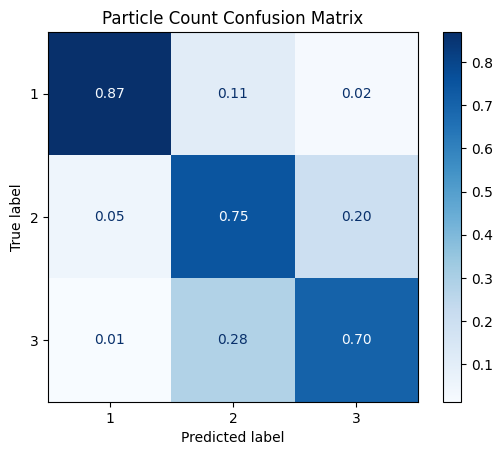

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(y_pix, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='.2f') # .2f shows 2 decimal places for percentages
plt.title('Particle Count Confusion Matrix')
plt.show()